# Model development

Final notebook that assumes all insights from `EDA.ipynb` and `Baseline.ipynb` to develop production model

## Download data

In [1]:
import pandas as pd 
import numpy as np
import sklearn

pd.set_option('display.max_columns', 200)
np.random.seed(42)

In [2]:
%pip install -q kagglehub

In [3]:
# download dataset from kaggle
import kagglehub # pyright: ignore[reportMissingImports]
from pathlib import Path

# Download latest version
path = Path(kagglehub.dataset_download("blastchar/telco-customer-churn"))
path = path / r"WA_Fn-UseC_-Telco-Customer-Churn.csv"

print("Path to dataset files:", path)
df = pd.read_csv(path)
df.head()

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Data preparation

In [4]:
from sklearn.preprocessing import LabelEncoder # type: ignore

to_category_columns = (
    [
        "gender",
        "Partner",
        "Dependents",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup", 
        "DeviceProtection",
        "TechSupport",
        "StreamingTV", 
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "Churn"
        ])
    
for column in to_category_columns:
    df[column] = df[column].astype("category")
    
df["SeniorCitizen"] = df["SeniorCitizen"] == 1
df["Churn"] = df["Churn"] == "Yes"
    
df["TotalCharges"]  = pd.to_numeric(df['TotalCharges'], errors='coerce')

df = df.dropna()
df["TotalCharges"].isna().sum()


print("Basic data preparation is done")
print(df.shape)


Basic data preparation is done
(7032, 21)


### Removing columns

In [5]:
# Drop customerId column as never significant
df = df.drop(columns=["customerID", "gender", "MultipleLines", "StreamingTV", "StreamingMovies"])
print("Dropping not significant columns")
print(df.shape)

print("Apply OHE for data")
df_ohe = pd.get_dummies(df)
print(df_ohe.shape)

Dropping not significant columns
(7032, 16)
Apply OHE for data
(7032, 35)


## Model building

I will use a GBDT approach as one of the most powerful in `Baseline.ipynb`

In [6]:
%pip install lightgbm -q

In [7]:
import lightgbm as lgb
from sklearn.model_selection import cross_val_predict, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report

churn_ratio = df_ohe.groupby("Churn")["Churn"].count()

X = df_ohe.drop(columns="Churn").copy()
y = df_ohe["Churn"].copy()

minor_base_scale = churn_ratio.iloc[0] / churn_ratio.iloc[1]
lgbm = lgb.LGBMClassifier(scale_pos_weight=minor_base_scale, verbose=-1)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_pred_cv = cross_val_predict(lgbm, X, y, cv=skf)
y_proba_cv = cross_val_predict(lgbm, X, y, cv=skf, method="predict_proba")[:, 1]
auc_scores = cross_val_score(lgbm, X, y, cv=skf, scoring='average_precision')
print(classification_report(y, y_pred_cv))
print(f"PR-AUC: {auc_scores.mean():.4f} +/- {auc_scores.std():.4f} (var: {auc_scores.var():.4f})")

              precision    recall  f1-score   support

       False       0.89      0.76      0.82      5163
        True       0.53      0.74      0.62      1869

    accuracy                           0.76      7032
   macro avg       0.71      0.75      0.72      7032
weighted avg       0.80      0.76      0.77      7032

PR-AUC: 0.6496 +/- 0.0113 (var: 0.0001)


### Model tuning

Lets tune model with optuna.

I will tune model both on PR-AUC score and recall metrics. At the final I will compare models via PR-AUC curves with cost analysis

In [8]:
%pip install optuna -q

In [9]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


In [10]:
from sklearn.model_selection import train_test_split
from functools import partial

import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve
from sklearn.model_selection import StratifiedKFold
from matplotlib.ticker import FuncFormatter


def objective(trial, metric_func, X_data, y_data, threshold=False):
    train_x, valid_x, train_y, valid_y = train_test_split(
        X_data, y_data, test_size=0.25, random_state=42
    )
    dtrain = lgb.Dataset(train_x, label=train_y)

    param = {
        "objective": "binary",
        "metric": "binary_logloss",
        "verbosity": -1,
        "seed": 42,
        "boosting_type": "gbdt",
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 2, 256),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.4, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.4, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 7),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
    }

    gbm = lgb.train(param, dtrain)
    preds = gbm.predict(valid_x)
    if threshold:
        preds = (preds > 0.5).astype(int)
    return metric_func(valid_y, preds)


FN_cost = 997.94
FP_cost = 89.33
retain_p = 0.45

def print_best_trial(study):
    print("Number of finished trials: {}".format(len(study.trials)))

    print("Best trial:")
    trial = study.best_trial

    print("  Value: {}".format(trial.value))

    print("  Params: ")
    for key, value in trial.params.items():
        print("    {}: {}".format(key, value))
        
        
def nested_cv_with_optuna(X, y, metric_func, n_trials=50, threshold=False,
                           n_outer=5, random_state=42):
    """Nested CV: outer loop for unbiased eval, inner Optuna for tuning on outer train only."""
    outer_skf = StratifiedKFold(n_splits=n_outer, shuffle=True, random_state=random_state)

    fold_money_saved = []
    fold_no_model_costs = []
    fold_best_costs = []
    all_oof_proba = np.zeros(len(y))

    for fold, (outer_train_idx, outer_test_idx) in enumerate(outer_skf.split(X, y)):
        X_outer_train, X_outer_test = X.iloc[outer_train_idx], X.iloc[outer_test_idx]
        y_outer_train, y_outer_test = y.iloc[outer_train_idx], y.iloc[outer_test_idx]

        study = optuna.create_study(direction="maximize")
        obj = partial(objective, metric_func=metric_func,
                      X_data=X_outer_train, y_data=y_outer_train, threshold=threshold)
        study.optimize(obj, n_trials=n_trials)
        
        best_params = study.best_trial.params
        best_params.update({"objective": "binary", "metric": "binary_logloss",
                           "verbosity": -1, "boosting_type": "gbdt"})

        lgbm_fold = lgb.LGBMClassifier(**best_params)
        lgbm_fold.fit(X_outer_train, y_outer_train)
        y_proba_fold = lgbm_fold.predict_proba(X_outer_test)[:, 1]
        all_oof_proba[outer_test_idx] = y_proba_fold

        precision, recall, thresholds = precision_recall_curve(y_outer_test, y_proba_fold)

        P_fold = y_outer_test.sum()
        TP = recall[:-1] * P_fold
        FN = P_fold - TP
        FP = TP * (1 / precision[:-1] - 1)
        total_costs = FN * FN_cost + FP_cost * FP + (FP_cost + (1 - retain_p) * FN_cost) * TP

        best_idx = np.argmin(total_costs)
        no_model_cost = P_fold * FN_cost
        fold_no_model_costs.append(no_model_cost)
        fold_best_costs.append(total_costs[best_idx])
        fold_money_saved.append(no_model_cost - total_costs[best_idx])

    return np.array(fold_money_saved), np.array(fold_no_model_costs), np.array(fold_best_costs), all_oof_proba


def compute_ci(fold_values):
    from scipy import stats
    n = len(fold_values)
    std = fold_values.std(ddof=1)
    # SE for the SUM across folds (not the mean) - Var(sum) ~ n * Var_fold under near-independence
    se_total = np.sqrt(n) * std
    ci95 = stats.t.ppf(0.975, df=n - 1) * se_total
    return std, ci95


def plot_cost_curve(thresholds, total_costs, no_model_cost, best_threshold, metric, retain_p=0.45):
    plt.figure(figsize=(10, 6))
    plt.plot(thresholds, total_costs, label=f"Retain chance: {retain_p*100:.0f}%", color="olive", linestyle="-.")
    plt.plot(thresholds, [no_model_cost] * len(thresholds), label="No model", color="black", linestyle="--")
    plt.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold: {best_threshold:.3f}")
    plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
    plt.xlabel("Threshold")
    plt.ylabel("Total Cost ($)")
    plt.title(f"Total Cost curve with optimized {metric} (45% Retention)")
    plt.legend()
    plt.show()


def plot_model_threshold_cost_curve(X, y, metric_func, metric_name,
                                     n_trials=50, threshold=False):
    fold_money_saved, fold_no_model_costs, fold_best_costs, all_oof_proba = \
        nested_cv_with_optuna(X, y, metric_func, n_trials, threshold)

    saved_std, saved_ci = compute_ci(fold_money_saved)
    no_model_std, no_model_ci = compute_ci(fold_no_model_costs)
    best_cost_std, best_cost_ci = compute_ci(fold_best_costs)

    P = y.sum()
    precision, recall, thresholds = precision_recall_curve(y, all_oof_proba)
    TP = recall[:-1] * P
    FN = P - TP
    FP = TP * (1 / precision[:-1] - 1)
    total_costs = FN * FN_cost + FP_cost * FP + (FP_cost + (1 - retain_p) * FN_cost) * TP
    best_idx = np.argmin(total_costs)
    best_threshold = thresholds[best_idx]
    best_cost = total_costs[best_idx]
    no_model_cost = P * FN_cost
    money_saved = no_model_cost - best_cost

    plot_cost_curve(thresholds, total_costs, no_model_cost, best_threshold, metric_name)

    print(f"Best threshold:  {best_threshold:.4f}")
    print(f"No-model cost:   ${no_model_cost:,.0f} \u00b1 ${no_model_std:,.0f} (95% CI: [${no_model_cost - no_model_ci:,.0f}, ${no_model_cost + no_model_ci:,.0f}])")
    print(f"Min model cost:  ${best_cost:,.0f} \u00b1 ${best_cost_std:,.0f} (95% CI: [${best_cost - best_cost_ci:,.0f}, ${best_cost + best_cost_ci:,.0f}])")
    print(f"Money saved:     ${money_saved:,.0f} \u00b1 ${saved_std:,.0f} (95% CI: [${money_saved - saved_ci:,.0f}, ${money_saved + saved_ci:,.0f}])")
    print(f"Money saved %:   {money_saved/no_model_cost*100:.2f}% \u00b1 {saved_std/no_model_cost*100:.2f}%")

### Optimizing PR-AUC score

In [11]:
params_study = optuna.create_study(direction="maximize")
shap_obj = partial(objective, metric_func=sklearn.metrics.average_precision_score,
                   X_data=X, y_data=y)
params_study.optimize(shap_obj, n_trials=50)
print_best_trial(params_study)

Number of finished trials: 50
Best trial:
  Value: 0.6510739216695243
  Params: 
    lambda_l1: 2.7580658438306074
    lambda_l2: 0.0011195303464912826
    num_leaves: 5
    feature_fraction: 0.7556401556833737
    bagging_fraction: 0.6111406490538761
    bagging_freq: 3
    min_child_samples: 20


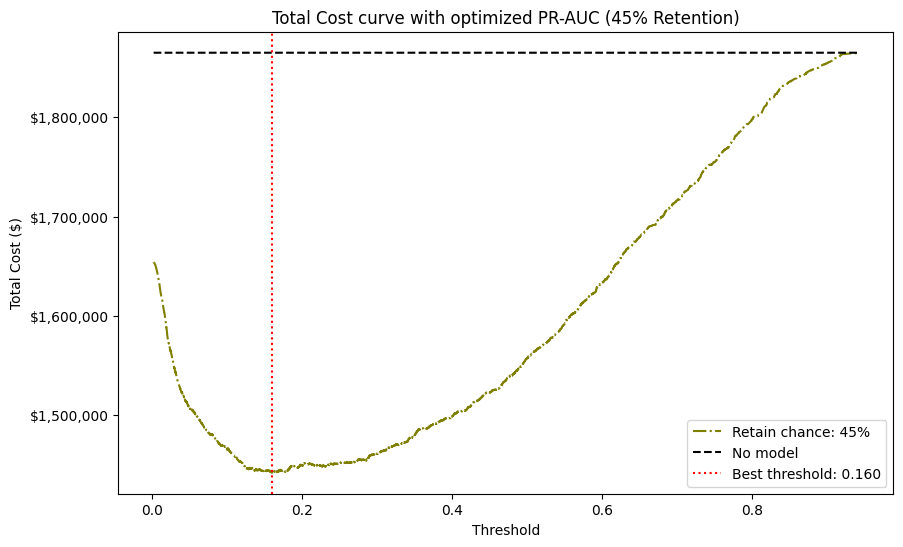

Best threshold:  0.1597
No-model cost:   $1,865,150 ± $446 (95% CI: [$1,862,379, $1,867,921])
Min model cost:  $1,441,965 ± $1,972 (95% CI: [$1,429,722, $1,454,207])
Money saved:     $423,185 ± $1,679 (95% CI: [$412,763, $433,607])
Money saved %:   22.69% ± 0.09%


In [12]:
plot_model_threshold_cost_curve(X, y, sklearn.metrics.average_precision_score, "PR-AUC", n_trials=50)

### Optimizing Recall

In [13]:
params_study = optuna.create_study(direction="maximize")
shap_obj = partial(objective, metric_func=sklearn.metrics.recall_score,
                   X_data=X, y_data=y, threshold=True)
params_study.optimize(shap_obj, n_trials=50)
print_best_trial(params_study)

Number of finished trials: 50
Best trial:
  Value: 0.5218340611353712
  Params: 
    lambda_l1: 0.000350740815649081
    lambda_l2: 1.9326257339963555e-06
    num_leaves: 248
    feature_fraction: 0.4449656531302541
    bagging_fraction: 0.4328232398627019
    bagging_freq: 1
    min_child_samples: 63


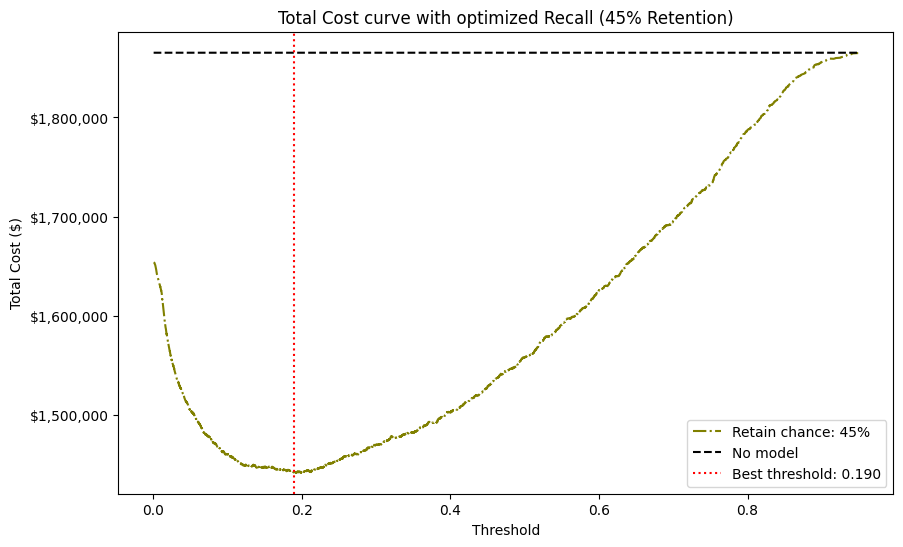

Best threshold:  0.1901
No-model cost:   $1,865,150 ± $446 (95% CI: [$1,862,379, $1,867,921])
Min model cost:  $1,442,115 ± $2,275 (95% CI: [$1,427,991, $1,456,239])
Money saved:     $423,035 ± $2,151 (95% CI: [$409,681, $436,389])
Money saved %:   22.68% ± 0.12%


In [14]:
plot_model_threshold_cost_curve(X, y, sklearn.metrics.recall_score, "Recall", n_trials=50, threshold=True)

The bottom line is that we can use both optimizations: AUC or Recall as they give not statistically different results.

All estimates above use **nested cross-validation** (5 outer folds, 50 Optuna trials per fold) to avoid model selection bias. Hyperparameters are tuned only on each outer training fold, and the cost estimates come from the held-out outer test folds that were never seen during tuning.

## Model interpretation

In [15]:
%pip install shap -q

In [16]:
# Train final model on full data for SHAP interpretation.
# Hyperparameter evaluation was already done via nested CV above;
# here we just need a reasonable model to explain.
shap_study = optuna.create_study(direction="maximize")
shap_obj = partial(objective, metric_func=sklearn.metrics.average_precision_score,
                   X_data=X, y_data=y)
shap_study.optimize(shap_obj, n_trials=50)

best_params = shap_study.best_trial.params
best_params.update({"objective": "binary", "metric": "binary_logloss", "verbosity": -1, "boosting_type": "gbdt"})

import shap

d_full = lgb.Dataset(X, label=y)
model = lgb.train(best_params, d_full)

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer(X)

Churn customer (index 2):


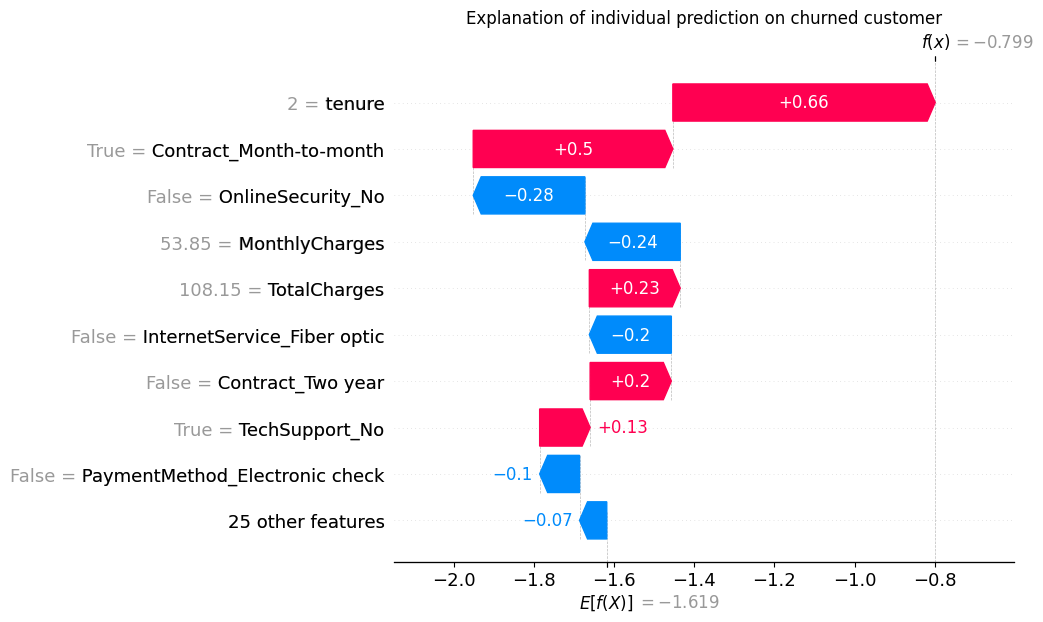


No-churn customer (index 0):


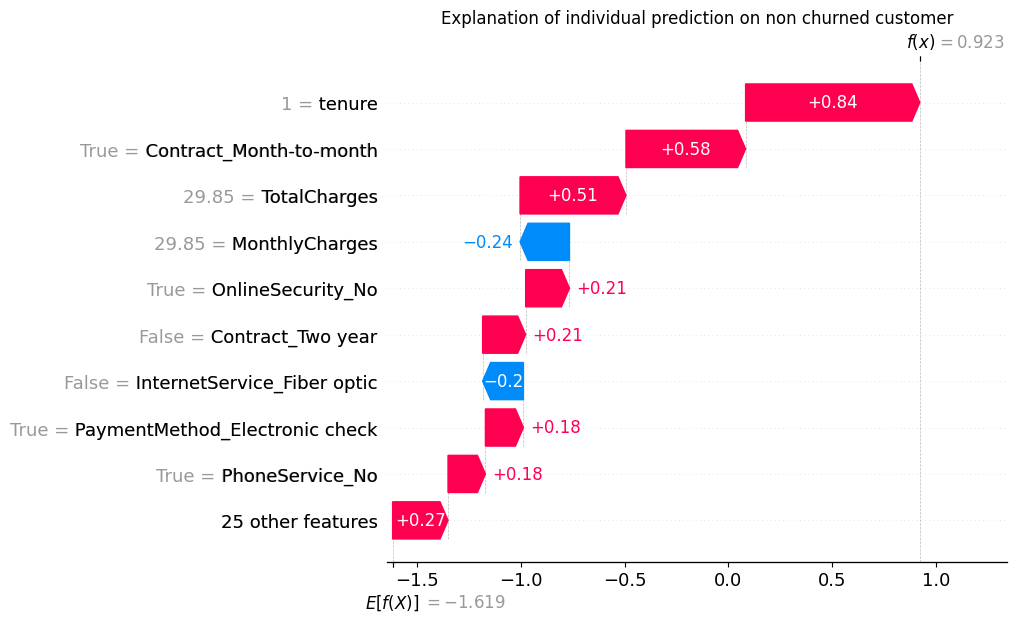

In [18]:
churn_idx = y[y].index[0]
no_churn_idx = y[~y].index[0]

print(f"Churn customer (index {churn_idx}):")
plt.title("Explanation of individual prediction on churned customer")
shap.waterfall_plot(shap_values[churn_idx])


print(f"\nNo-churn customer (index {no_churn_idx}):")
plt.title("Explanation of individual prediction on non churned customer")
shap.waterfall_plot(shap_values[no_churn_idx])


These plots are represent model choice for prediction in both cases: churned customer and not churned. Both plots are understandable. Final interpretation will be after the summary plot

/tmp/ipykernel_6106/3017445420.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X)


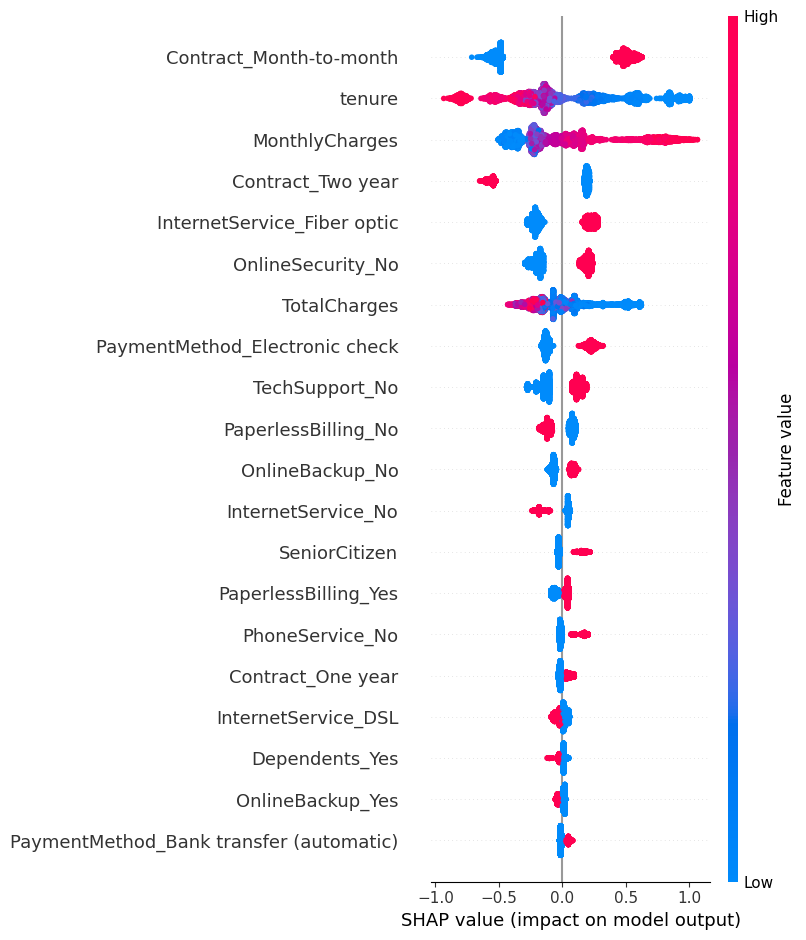

In [19]:
shap.summary_plot(shap_values, X)

From the plots we can gather final thoughts about interpretation. I will focus on most impactful features.

- The biggest predicting influence comes from contract type (Month to month or two years contract). Customers with month to month paying model tends to leave (See both on individual prediction plot)
- Model predict customers with high tenure staying. While customers with low tenure will not stay. Note that tenure at SHAP $\approx$ 0 (customers with average tenure) zone do not bring significant predicting effect (purple cluster at tenure axis)
- Monthly charges also matter for predicting. Model predict customer to churn if monthly charges are big. And tend to stay with low monthly charges. Average monthly charges do not bring significant impact.
- Customers without tech support seems to model as potential churning
- There is logical discrepancy in customers with total charges. Model mostly seems not churning customers with low total charges. And there is a bif variance in high total_charges values (purple cluster). That can mean that data contain specific pattern for specific category of total charges. Maybe some interval of total charges at low values is extremely useful. Or that can be leaded from multicollinearity (as total charges = tenure * monthly charges ). SHAP can contain this feature cause both tenure and month charges are useful in predictions, creating this artifact in plot.

In plain text model the churning customer for a model is a new customers with high bills and month to month contract. This theory is fully accepted from business side and even expands EDA hypothesis of churning customers (include month to month contract influence)

## Conclusion

The model enables significant cost reduction through targeted retention efforts. Based on the cost analysis:
- **Cost of false negative (missed churn)**: $997.94
- **Cost of false positive (unnecessary retention offer)**: $89.33
- **Retention success probability**: 45% (according to [Harvard Business Review](https://static.fecredit.com.vn/Document/Th%C6%B0%20Vi%E1%BB%87n%20S%C3%A1ch/Merged/Mar%2016/Part%201.pdf) (22 page, "Marketing winning back lost customers"). *Should* be A/B tested for final results)

### Key Drivers of Churn

SHAP-based model interpretation revealed the following most influential features:

1. **Contract type**: Month-to-month customers are substantially more likely to churn than those with long-term contracts
2. **Tenure**: New customers (low tenure) have higher churn risk; long-tenured customers are more likely to stay
3. **Monthly charges**: Higher monthly bills correlate with increased churn probability
4. **Tech support**: Absence of tech support service is associated with higher churn
5. **Total charges**: Lower total charges indicate newer customers, contributing to churn prediction

The model aligns with business intuition: high-risk customers are typically new subscribers on month-to-month contracts with elevated monthly charges and no value-added services.

### Limitations

- The analysis relies on a historical dataset; model performance should be validated on current data
- Temporal dynamics (e.g., seasonal churn patterns) were not explicitly modeled
- Total charges showed multicollinearity with tenure and monthly charges, which may introduce noise